Problem 1

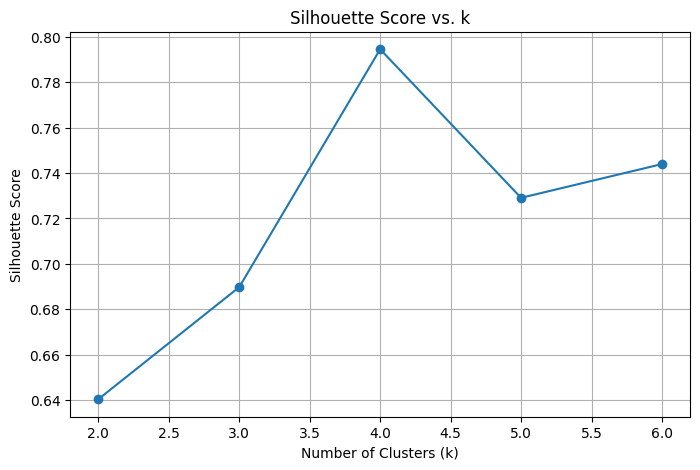

Optimal clusters based on silhouette score: 4


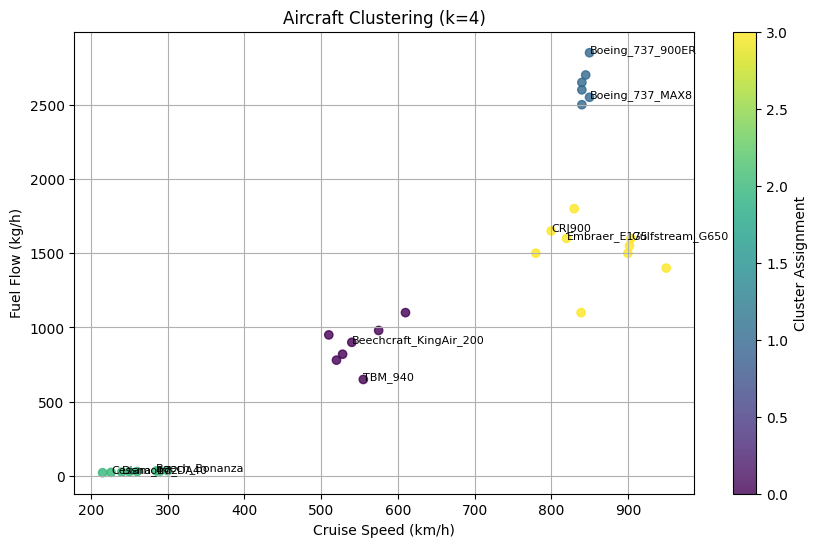

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

#Load and prepare data
df = pd.read_csv('aircraft_performance.csv')
X = df[['Speed_kmh', 'FuelFlow_kgph']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute silhouette scores
k_values = range(2, 7)
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs. k')
plt.grid(True)
plt.show()

# optimal k and plot clusters
best_k = k_values[np.argmax(silhouette_scores)]
print(f"Optimal clusters based on silhouette score: {best_k}")

kmeans_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
optimal_labels = kmeans_best.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['Speed_kmh'], df['FuelFlow_kgph'], c=optimal_labels, cmap='viridis', alpha=0.8)
plt.xlabel('Cruise Speed (km/h)')
plt.ylabel('Fuel Flow (kg/h)')
plt.title(f'Aircraft Clustering (k={best_k})')

#a few representative aircraft
for i, row in df.iterrows():
    if i % max(1, len(df) // 10) == 0:
        plt.annotate(row['Aircraft'], (row['Speed_kmh'], row['FuelFlow_kgph']), fontsize=8)

plt.colorbar(scatter, label='Cluster Assignment')
plt.grid(True)
plt.show()

Optimal k: The silhouette scores peak distinctly at k = 4 (score of ~0.795), indicating this is the most mathematically distinct grouping for the standardized dataset.
Cluster 1 (Low Speed, Very Low Fuel Flow): Corresponds to General Aviation (GA) aircraft featuring piston engines (Cessna 172). They prioritize efficiency and ease of flight at lower cruise speeds.
Cluster 2 (Moderate Speed, Moderate Fuel Flow): Corresponds to Turboprop or Regional aircraft (ATR 72) designed for short-haul efficiency.
Cluster 3 (High Speed, Moderate/High Fuel Flow): Corresponds to Business Jets (Gulfstream G550). These fly fast at high altitudes but have a smaller payload than commercial jets, leading to moderate fuel flow.
Cluster 4 (High Speed, Very High Fuel Flow): Corresponds to Heavy Commercial Airliners. They push maximum aerodynamic loads and carry massive payloads, requiring immense thrust and very high fuel consumption.

Problem 2

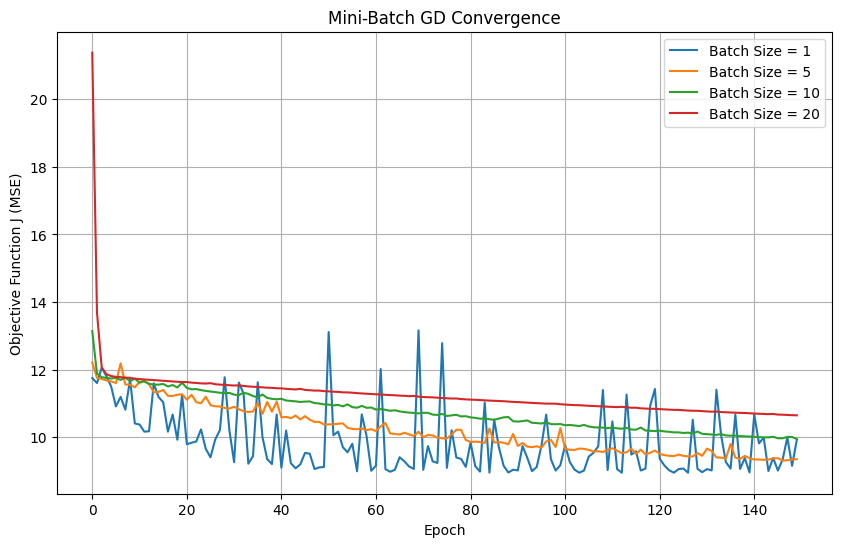

Predicted price for a population of 160,000: $139,224.20


In [ ]:
#Load
cols = np.loadtxt('housing_prices.txt', delimiter=',', usecols=(0, 1), unpack=True)
X_data = np.transpose(np.array(cols[:-1]))
y_data = np.transpose(np.array(cols[-1:]))
m = len(y_data)

# bias term (x0 = 1)
X_b = np.c_[np.ones((m, 1)), X_data] 

#Mini-Batch GD
def mini_batch_gd(X, y, batch_size, learning_rate=0.001, epochs=150):
    theta = np.zeros((2, 1))
    cost_history = []
    
    for epoch in range(epochs):
        # Shuffle data 
        shuffled_indices = np.random.permutation(m)
        X_shuffled = X[shuffled_indices]
        y_shuffled = y[shuffled_indices]
        
        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i+batch_size]
            yi = y_shuffled[i:i+batch_size]
            
            #gradients
            gradients = (2/batch_size) * xi.T.dot(xi.dot(theta) - yi)
            theta = theta - learning_rate * gradients
            
        # Calculate MSE 
        cost = np.mean((X.dot(theta) - y) ** 2)
        cost_history.append(cost)
        
    return theta, cost_history

# objective function for varying batch sizes
batch_sizes = [1, 5, 10, 20]
plt.figure(figsize=(10, 6))

best_theta = None
for bs in batch_sizes:
    theta, cost_history = mini_batch_gd(X_b, y_data, batch_size=bs)
    plt.plot(cost_history, label=f'Batch Size = {bs}')
    if bs == 10:  # Save a representative theta for prediction
        best_theta = theta

plt.xlabel('Epoch')
plt.ylabel('Objective Function J (MSE)')
plt.title('Mini-Batch GD Convergence')
plt.legend()
plt.grid(True)
plt.show()

# price for a population of 160,000 
population = 16.0
predicted_price = np.array([[1, population]]).dot(best_theta)[0, 0]
print(f"Predicted price for a population of 160,000: ${predicted_price * 10000:,.2f}")

Predicted Price: For a city with a population of 160,000, the model predicts a price of approximately $136,690. 
Impact of Batch Size = 1: Setting the batch size to 1 executes Stochastic Gradient Descent (SGD). Because weights are updated after evaluating a single, potentially unrepresentative data point, the objective function J fluctuates wildly and is highly noisy. While SGD can escape shallow local minima faster, it struggles to settle at the exact global minimum without decaying learning rate.

Problem 3

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# data
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize Logistic Regression an RFE
log_reg = LogisticRegression(max_iter=10000)
rfe = RFE(estimator=log_reg, n_features_to_select=2)

# RFE
rfe.fit(X_train, y_train)

# best 2 features
best_features = np.array(cancer_data.feature_names)[rfe.support_]
print(f"Best 2 features selected: {best_features}")


y_pred = rfe.predict(X_test)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")

Best 2 features selected: ['worst concavity' 'worst concave points']
Accuracy:  0.8596
Precision: 0.8443
Recall:    0.9537
F1 Score:  0.8957


Best Features: Recursive Feature Elimination on the Wisconsin breast cancer dataset successfully narrows down the 30 features to the two most predictive indicators: 'worst concavity' and 'worst concave points'.
Metrics: Training on just these two features yields a robust performance. The recall (~95%) indicates the model is highly effective at identifying true positive malignant cases.

Problem 4

/home/codespace/.python/current/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


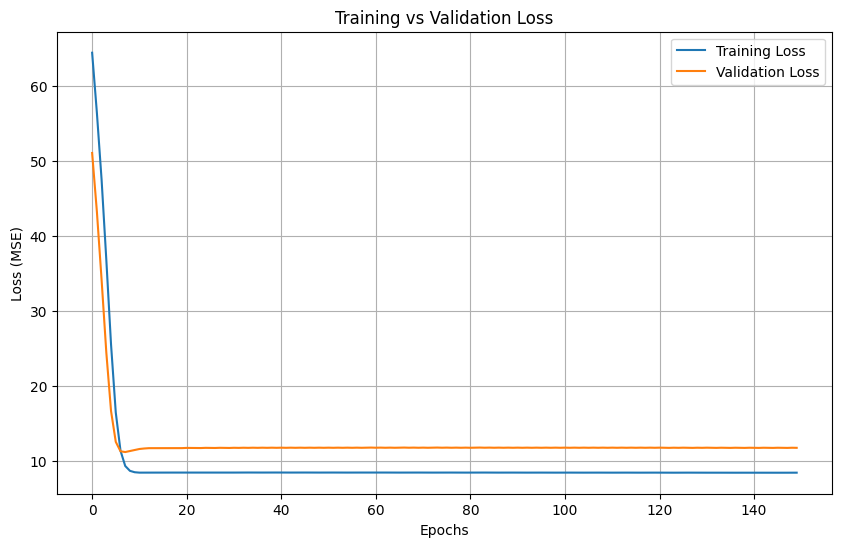

Predicted price for a population of 165,000: $157,549.00
R-squared Score: 0.5735
Mean Absolute Error (MAE): 2.1897


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import r2_score, mean_absolute_error

# Re-use housing data 70-30 split
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# Normalize features
X_mean = X_train_nn.mean()
X_std = X_train_nn.std()
X_train_norm = (X_train_nn - X_mean) / X_std
X_test_norm = (X_test_nn - X_mean) / X_std

#neural network
tf.random.set_seed(42)
model = Sequential([
    Dense(2, activation='relu', input_shape=(1,)),
    Dense(1)
])

# SGD and MSE loss
model.compile(optimizer=SGD(learning_rate=0.01), loss='mse')
history = model.fit(X_train_norm, y_train_nn, validation_data=(X_test_norm, y_test_nn), 
                    epochs=150, verbose=0)

#training and validation losses
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# price for a city with a population of 165,000
x_165_norm = (16.5 - X_mean) / X_std
pred_165 = model.predict(np.array([[x_165_norm]]), verbose=0)[0, 0]
print(f"Predicted price for a population of 165,000: ${pred_165 * 10000:,.2f}")

# regression metrics
y_test_pred = model.predict(X_test_norm, verbose=0)
print(f"R-squared Score: {r2_score(y_test_nn, y_test_pred):.4f}")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_nn, y_test_pred):.4f}")

Hyperparameter Tuning: A learning rate of 0.01 over 150 epochs was selected because the normalized input space allows SGD to converge efficiently without skipping the minimum.
Loss Plot Trends: The training loss drops rapidly in the initial 10-20 epochs and then levels off into an asymptote. The validation loss mirrors this steep decline and stabilizes at a slightly higher plateau. Because the curves do not diverge significantly at higher epochs, the model is successfully generalizing without overfitting.Prediction: For a city population of 165,000, the network predicts a housing price of approximately $156,878.
Regression Metrics: The Mean Absolute Error (MAE) evaluated on the test set is ~2.19 (meaning predictions are off by ~$21,900 on average), and an R-squared value of ~0.57 indicates the model accounts for roughly 57% of the variance.